# **PRÁTICA 3**
# Membership Inference Attack

________________________________________________________

#### SEMATEC 2026
**Curso**: Hackeando uma IA - Técnicas de Ataque e Defesa em Modelos de Difusão

**Prof.:** Jean Phelipe de Oliveira Lima

________________________________________________________
### **!!! AVISO: Para esta atividade, recomenda-se o uso de GPU!!!**
________________________________________________________


#### Setup inicial

In [17]:
!pip install -q diffusers==0.35.1 accelerate==1.10.1 scikit-learn==1.6.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 108.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 30.2 MB/s eta 0:00:00


In [18]:
import os
import re
import glob
import random
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn.functional as F

from torchvision import transforms

from diffusers import (
    UNet2DModel,
    DDPMScheduler,
    DDIMScheduler,
    DDPMPipeline
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score
)

In [19]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [20]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Dispositivo:", device)

if device.type != "cuda":
    raise RuntimeError(
        "Ative uma GPU no Google Colab antes de continuar."
    )

print("GPU:", torch.cuda.get_device_name(0))

Dispositivo: cuda
GPU: Tesla T4


In [21]:
from google.colab import files

uploaded = files.upload()

Saving dados.zip to dados.zip


## Carregar dados

In [22]:
nome_zip = next(iter(uploaded.keys()))

pasta_dados = "/content/dados_ddpm"

os.makedirs(
    pasta_dados,
    exist_ok=True
)

with zipfile.ZipFile(nome_zip, "r") as arquivo_zip:
    arquivo_zip.extractall(pasta_dados)

In [23]:
encontrados = glob.glob(
    os.path.join(pasta_dados, "**", "*"),
    recursive=True
)

mapa_arquivos = {}

for caminho in encontrados:
    nome = os.path.basename(caminho).lower()

    padrao = r"rosto(0[1-9]|10)\.(png|jpg|jpeg)"

    if re.fullmatch(padrao, nome):
        numero = int(
            re.search(r"\d+", nome).group()
        )

        mapa_arquivos[numero] = caminho

### Verifica Dados importados

In [81]:
faltantes = [
    numero
    for numero in range(1, 11)
    if numero not in mapa_arquivos
]

if faltantes:
    raise FileNotFoundError(
        f"Imagens não encontradas: {faltantes}"
    )

caminhos = [
    mapa_arquivos[numero]
    for numero in range(1, 11)
]

print("As dez imagens foram encontradas.")

for caminho in caminhos:
    print(os.path.basename(caminho))

As dez imagens foram encontradas.
rosto01.png
rosto02.png
rosto03.png
rosto04.png
rosto05.png
rosto06.png
rosto07.png
rosto08.png
rosto09.png
rosto10.png


## Visualização dos Dados

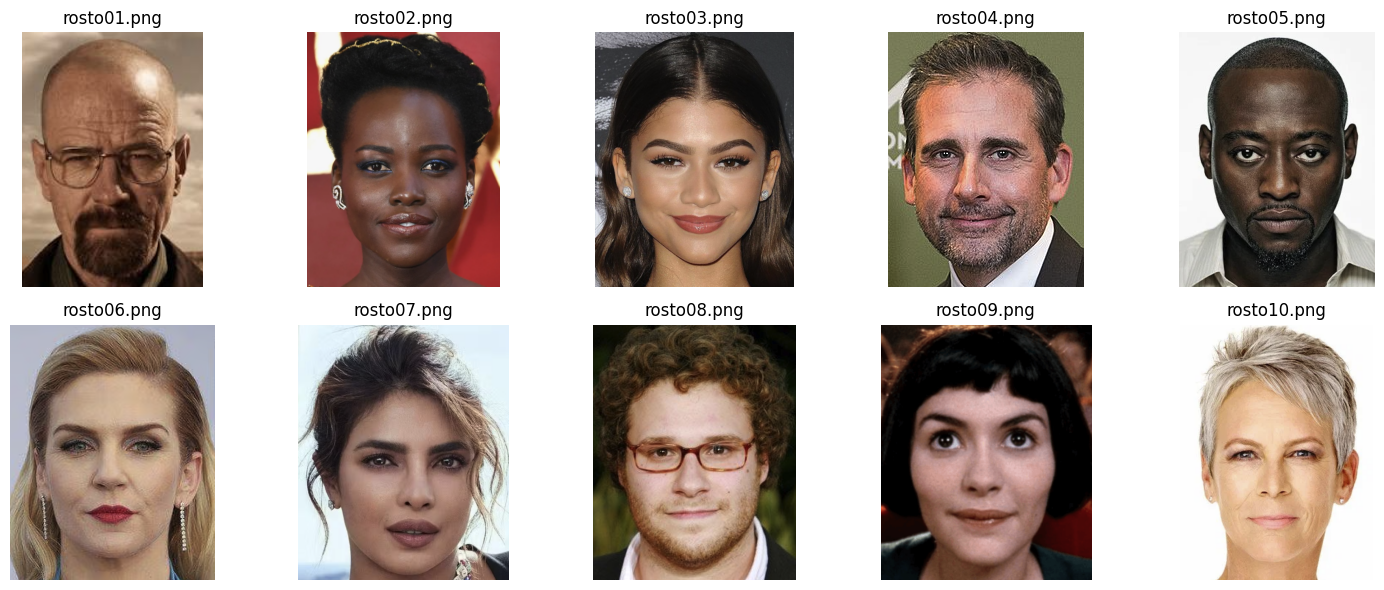

In [82]:
plt.figure(figsize=(15, 6))

for i, caminho in enumerate(caminhos):

    imagem = Image.open(caminho).convert("RGB")

    plt.subplot(2, 5, i + 1)
    plt.imshow(imagem)
    plt.title(f"rosto{i+1:02d}.png")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Pipeline de Pré-Processamento

In [26]:
preprocessamento = transforms.Compose([
    transforms.Resize(72),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [83]:
def carregar_tensor(caminho):

    imagem = Image.open(caminho).convert("RGB")

    tensor = preprocessamento(imagem)

    return tensor

In [84]:
todas_imagens = torch.stack([
    carregar_tensor(caminho)
    for caminho in caminhos
])

print("Formato:", todas_imagens.shape)
print("Menor valor:", todas_imagens.min().item())
print("Maior valor:", todas_imagens.max().item())

Formato: torch.Size([10, 3, 64, 64])
Menor valor: -1.0
Maior valor: 1.0


## Partição do Dataset

In [85]:
imagens_treino = todas_imagens[:5]

In [86]:
imagens_nao_membros = todas_imagens[5:]

In [87]:
print(
    "Imagens de treinamento:",
    imagens_treino.shape
)

print(
    "Imagens não membros:",
    imagens_nao_membros.shape
)

Imagens de treinamento: torch.Size([5, 3, 64, 64])
Imagens não membros: torch.Size([5, 3, 64, 64])


In [88]:
def tensor_para_imagem(tensor):

    imagem = tensor.detach().cpu()

    # Converte de [-1, 1] para [0, 1]
    imagem = (imagem + 1) / 2

    # Garante que os valores fiquem entre 0 e 1
    imagem = imagem.clamp(0, 1)

    # Converte de [canais, altura, largura]
    # para [altura, largura, canais]
    imagem = imagem.permute(1, 2, 0)

    return imagem

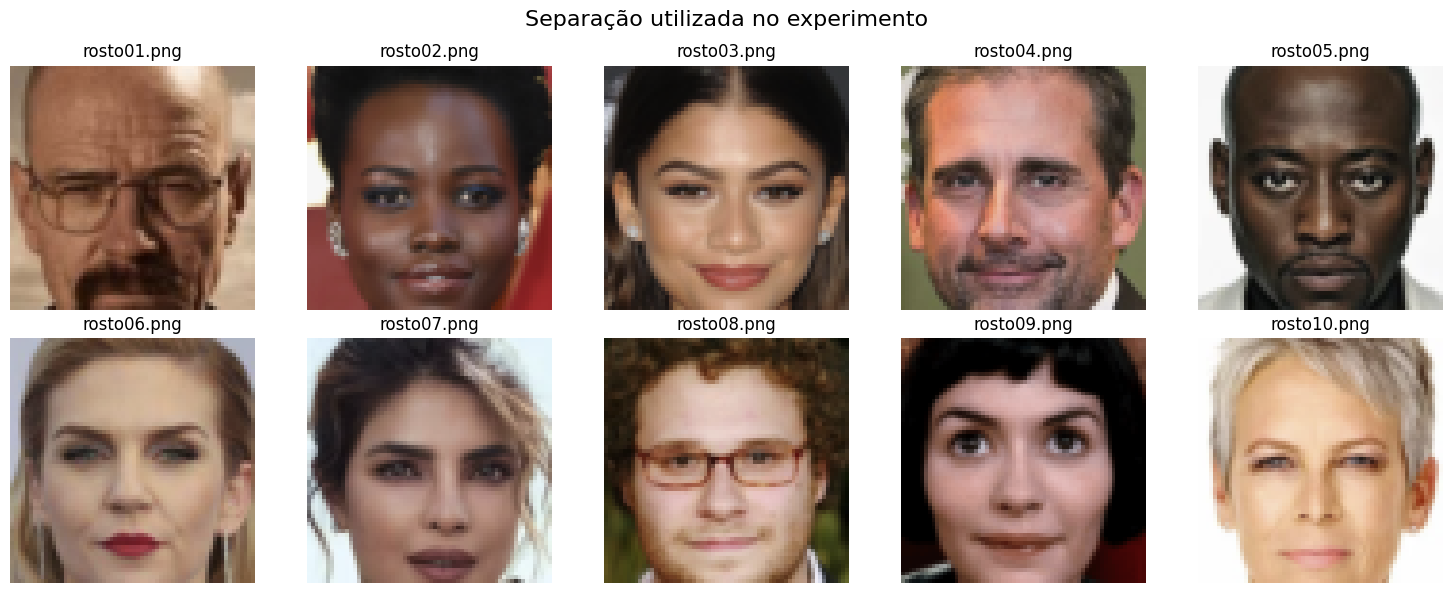

In [89]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 6)
)

# Primeira linha: membros do treinamento
for i in range(5):

    axes[0, i].imshow(
        tensor_para_imagem(imagens_treino[i])
    )

    axes[0, i].set_title(
        f"rosto{i+1:02d}.png"
    )

    axes[0, i].axis("off")

# Segunda linha: não membros
for i in range(5):

    axes[1, i].imshow(
        tensor_para_imagem(imagens_nao_membros[i])
    )

    axes[1, i].set_title(
        f"rosto{i+6:02d}.png"
    )

    axes[1, i].axis("off")

axes[0, 0].set_ylabel(
    "Treinamento",
    fontsize=13
)

axes[1, 0].set_ylabel(
    "Não membros",
    fontsize=13
)

plt.suptitle(
    "Separação utilizada no experimento",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Construção da Rede Neural

In [105]:
unet = UNet2DModel(
    sample_size=64,

    # A entrada é uma imagem RGB
    in_channels=3,

    # A saída é a previsão de ruído para cada canal
    out_channels=3,

    # Número de blocos residuais em cada nível
    layers_per_block=2,

    # Quantidade de canais internos
    block_out_channels=(
        64,
        128,
        128
    ),

    # Caminho de compressão
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D"
    ),

    # Caminho de expansão
    up_block_types=(
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D"
    ),

    norm_num_groups=8
)

In [106]:
unet = unet.to(device)

In [107]:
quantidade_parametros = sum(
    parametro.numel()
    for parametro in unet.parameters()
)

print(
    f"Parâmetros da U-Net: "
    f"{quantidade_parametros:,}"
)

Parâmetros da U-Net: 6,472,195


## Configs do DDPM

In [108]:
noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    beta_schedule="linear",
    prediction_type="epsilon"
)

In [109]:
num_train_timesteps=1000

In [110]:
prediction_type="epsilon"

In [111]:
betas = noise_scheduler.betas.cpu().numpy()

alphas = noise_scheduler.alphas.cpu().numpy()

alphas_barra = (
    noise_scheduler.alphas_cumprod
    .cpu()
    .numpy()
)

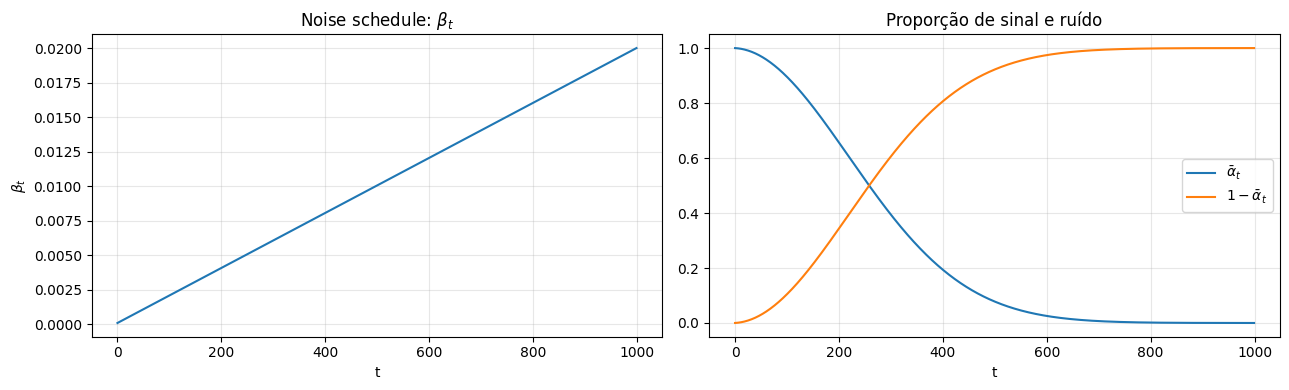

In [112]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4)
)

axes[0].plot(betas)
axes[0].set_title(
    r"Noise schedule: $\beta_t$"
)
axes[0].set_xlabel("t")
axes[0].set_ylabel(
    r"$\beta_t$"
)
axes[0].grid(alpha=0.3)

axes[1].plot(
    alphas_barra,
    label=r"$\bar{\alpha}_t$"
)

axes[1].plot(
    1 - alphas_barra,
    label=r"$1-\bar{\alpha}_t$"
)

axes[1].set_title(
    "Proporção de sinal e ruído"
)

axes[1].set_xlabel("t")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Preparando para Treino

In [113]:
NUM_PASSOS = 2500
BATCH_SIZE = 5
LEARNING_RATE = 2e-4

In [114]:
optimizer = torch.optim.AdamW(
    unet.parameters(),
    lr=LEARNING_RATE
)

In [115]:
scaler = torch.amp.GradScaler("cuda")

In [116]:
historico_loss = []

## Treino do Modelo

In [117]:
unet.train()

for passo in range(1, NUM_PASSOS + 1):

    # Sorteia imagens do conjunto de treinamento
    indices = torch.randint(
        low=0,
        high=len(imagens_treino),
        size=(BATCH_SIZE,)
    )

    x0 = imagens_treino[indices].to(device)

    # Sorteia um ruído diferente para cada imagem
    epsilon = torch.randn_like(x0)

    # Sorteia um instante t diferente para cada imagem
    t = torch.randint(
        low=0,
        high=noise_scheduler.config.num_train_timesteps,
        size=(BATCH_SIZE,),
        device=device
    ).long()

    # Produz xt diretamente a partir de x0
    xt = noise_scheduler.add_noise(
        x0,
        epsilon,
        t
    )

    # Limpa os gradientes do passo anterior
    optimizer.zero_grad(set_to_none=True)

    # Executa a U-Net
    with torch.amp.autocast(
        "cuda",
        dtype=torch.float16
    ):

        epsilon_previsto = unet(
            xt,
            t
        ).sample

        loss = F.mse_loss(
            epsilon_previsto.float(),
            epsilon.float()
        )

    # Backpropagation e atualização dos pesos
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    historico_loss.append(loss.item())

    # Mostra o progresso
    if passo == 1 or passo % 100 == 0:

        media_recente = np.mean(
            historico_loss[-100:]
        )

        print(
            f"Passo {passo:4d}/{NUM_PASSOS} "
            f"| loss média = {media_recente:.6f}"
        )

Passo    1/2500 | loss média = 1.061436
Passo  100/2500 | loss média = 0.144538
Passo  200/2500 | loss média = 0.065859
Passo  300/2500 | loss média = 0.042699
Passo  400/2500 | loss média = 0.039450
Passo  500/2500 | loss média = 0.039267
Passo  600/2500 | loss média = 0.037326
Passo  700/2500 | loss média = 0.027518
Passo  800/2500 | loss média = 0.025081
Passo  900/2500 | loss média = 0.019239
Passo 1000/2500 | loss média = 0.017808
Passo 1100/2500 | loss média = 0.019457
Passo 1200/2500 | loss média = 0.017855
Passo 1300/2500 | loss média = 0.017909
Passo 1400/2500 | loss média = 0.014325
Passo 1500/2500 | loss média = 0.013562
Passo 1600/2500 | loss média = 0.013562
Passo 1700/2500 | loss média = 0.012738
Passo 1800/2500 | loss média = 0.010689
Passo 1900/2500 | loss média = 0.009000
Passo 2000/2500 | loss média = 0.009616
Passo 2100/2500 | loss média = 0.010764
Passo 2200/2500 | loss média = 0.011369
Passo 2300/2500 | loss média = 0.012173
Passo 2400/2500 | loss média = 0.008667


## Avaliação do Treino

In [118]:
janela = 50

media_movel = np.convolve(
    historico_loss,
    np.ones(janela) / janela,
    mode="valid"
)

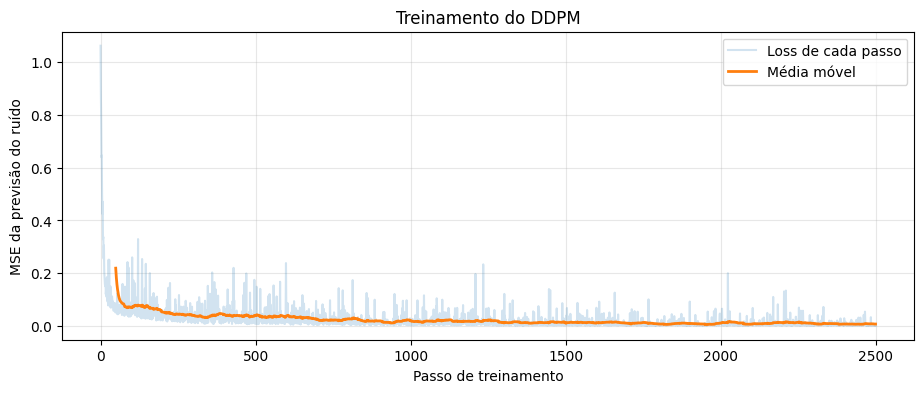

In [119]:
plt.figure(figsize=(11, 4))

plt.plot(
    historico_loss,
    alpha=0.2,
    label="Loss de cada passo"
)

plt.plot(
    range(
        janela - 1,
        len(historico_loss)
    ),
    media_movel,
    linewidth=2,
    label="Média móvel"
)

plt.xlabel("Passo de treinamento")
plt.ylabel("MSE da previsão do ruído")
plt.title("Treinamento do DDPM")

plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Ataque

In [120]:
TIMESTEPS_ATAQUE = [
    50,
    100,
    200,
    400,
    600
]

REPETICOES_POR_T = 10

In [57]:
@torch.no_grad() # Não atualiza pesos
def calcular_scores(
    modelo,
    imagens,
    timesteps,
    repeticoes
):

    # Modo de avaliação:
    # os pesos não serão atualizados
    modelo.eval()

    imagens = imagens.to(device)

    # Uma posição para acumular o erro de cada imagem
    soma_erros = torch.zeros(
        len(imagens),
        device=device
    )

    quantidade_medidas = 0

    for valor_t in timesteps:

        # Todas as dez imagens são testadas
        # no mesmo instante t
        t = torch.full(
            size=(len(imagens),),
            fill_value=valor_t,
            device=device,
            dtype=torch.long
        )

        for _ in range(repeticoes):

            # Sorteamos um ruído para cada imagem
            epsilon = torch.randn_like(imagens)

            # Aplicamos o processo direto
            xt = noise_scheduler.add_noise(
                imagens,
                epsilon,
                t
            )

            # A rede tenta prever o ruído
            with torch.amp.autocast(
                "cuda",
                dtype=torch.float16
            ):

                epsilon_previsto = modelo(
                    xt,
                    t
                ).sample

            # MSE individual de cada imagem
            erro_por_imagem = (
                epsilon_previsto.float()
                - epsilon.float()
            ).pow(2).mean(
                dim=(1, 2, 3)
            )

            soma_erros += erro_por_imagem

            quantidade_medidas += 1

    # Média das 50 medições
    scores = (
        soma_erros / quantidade_medidas
    )

    return scores.cpu().numpy()

In [121]:
scores = calcular_scores(
    modelo=unet,
    imagens=todas_imagens,
    timesteps=TIMESTEPS_ATAQUE,
    repeticoes=REPETICOES_POR_T
)

print("Scores calculados:")
print(scores)

Scores calculados:
[0.00821937 0.00953195 0.00875928 0.01123593 0.00937536 0.10727603
 0.13338429 0.1279761  0.12632345 0.11522979]


In [122]:
nomes = [
    f"rosto{i:02d}.png"
    for i in range(1, 11)
]

In [123]:
ordem = np.argsort(scores)

In [124]:
ranking = pd.DataFrame({
    "imagem": [
        nomes[indice]
        for indice in ordem
    ],

    "score": [
        scores[indice]
        for indice in ordem
    ]
})

ranking.index = range(
    1,
    len(ranking) + 1
)

ranking.index.name = "posição"

display(
    ranking.style.format({
        "score": "{:.6f}"
    })
)

,imagem,score
posição,,
1,rosto01.png,0.008219
2,rosto03.png,0.008759
3,rosto05.png,0.009375
4,rosto02.png,0.009532
5,rosto04.png,0.011236
6,rosto06.png,0.107276
7,rosto10.png,0.115230
8,rosto09.png,0.126323
9,rosto08.png,0.127976


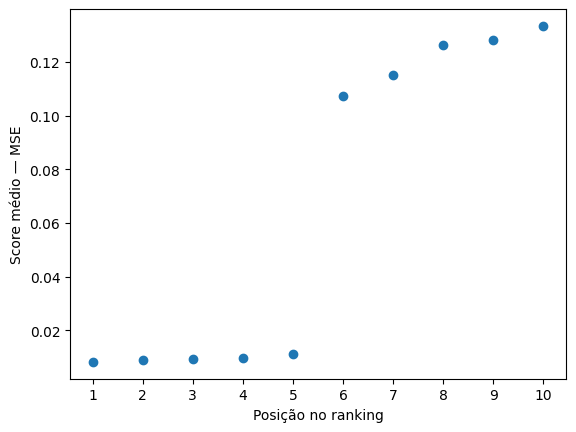

In [126]:
plt.scatter(
    ranking.index,
    ranking["score"]
)

plt.xticks(ranking.index)
plt.xlabel("Posição no ranking")
plt.ylabel("Score médio — MSE")

plt.show()

In [133]:
previsoes = np.zeros(
    10,
    dtype=int
)

# Menores losses são classificadas como membros
previsoes[ordem[:5]] = 1

In [134]:
ranking["decisão do atacante"] = [
    (
        "membro"
        if previsoes[indice] == 1
        else "não membro"
    )
    for indice in ordem
]

display(
    ranking.style.format({
        "score": "{:.6f}"
    })
)

,imagem,score,decisão do atacante
posição,,,
1,rosto01.png,0.008219,membro
2,rosto03.png,0.008759,membro
3,rosto05.png,0.009375,membro
4,rosto02.png,0.009532,membro
5,rosto04.png,0.011236,membro
6,rosto06.png,0.107276,não membro
7,rosto10.png,0.115230,não membro
8,rosto09.png,0.126323,não membro
9,rosto08.png,0.127976,não membro


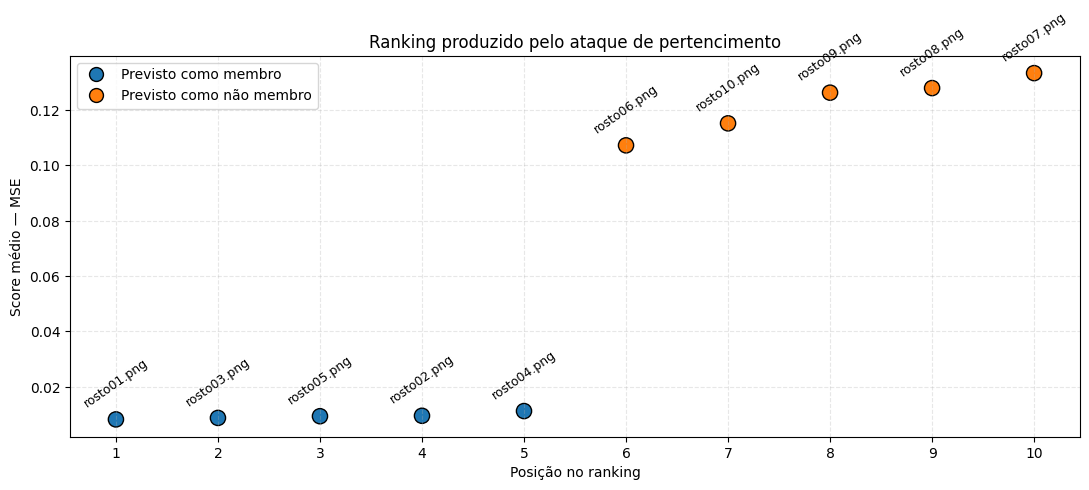

In [135]:
cores = ranking["decisão do atacante"].map({
    "membro": "tab:blue",
    "não membro": "tab:orange"
})

plt.figure(figsize=(11, 5))

plt.scatter(
    ranking.index,
    ranking["score"],
    c=cores,
    s=120,
    edgecolor="black"
)

for posicao, linha in ranking.iterrows():

    plt.annotate(
        linha["imagem"],
        xy=(
            posicao,
            linha["score"]
        ),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        rotation=35
    )

from matplotlib.lines import Line2D

legenda = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="white",
        markerfacecolor="tab:blue",
        markeredgecolor="black",
        markersize=10,
        label="Previsto como membro"
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        color="white",
        markerfacecolor="tab:orange",
        markeredgecolor="black",
        markersize=10,
        label="Previsto como não membro"
    )
]

plt.xticks(
    ranking.index
)

plt.xlabel(
    "Posição no ranking"
)

plt.ylabel(
    "Score médio — MSE"
)

plt.title(
    "Ranking produzido pelo ataque de pertencimento"
)

plt.grid(
    alpha=0.3,
    linestyle="--"
)

plt.legend(
    handles=legenda
)

plt.tight_layout()
plt.show()

In [136]:
rotulos_reais = np.array([
    1, 1, 1, 1, 1,
    0, 0, 0, 0, 0
])

In [137]:
ranking["resposta verdadeira"] = [
    (
        "membro"
        if rotulos_reais[indice] == 1
        else "não membro"
    )
    for indice in ordem
]

In [138]:
ranking["acertou"] = [
    previsoes[indice] == rotulos_reais[indice]
    for indice in ordem
]

In [139]:
display(
    ranking.style.format({
        "score": "{:.6f}"
    })
)

,imagem,score,decisão do atacante,resposta verdadeira,acertou
posição,,,,,
1,rosto01.png,0.008219,membro,membro,True
2,rosto03.png,0.008759,membro,membro,True
3,rosto05.png,0.009375,membro,membro,True
4,rosto02.png,0.009532,membro,membro,True
5,rosto04.png,0.011236,membro,membro,True
6,rosto06.png,0.107276,não membro,não membro,True
7,rosto10.png,0.115230,não membro,não membro,True
8,rosto09.png,0.126323,não membro,não membro,True
9,rosto08.png,0.127976,não membro,não membro,True


In [140]:
def colorir_resultado(valor):

    if valor is True:
        return "background-color: #b7e4c7"

    if valor is False:
        return "background-color: #ffccd5"

    return ""

In [141]:
display(
    ranking.style
    .format({
        "score": "{:.6f}"
    })
    .map(
        colorir_resultado,
        subset=["acertou"]
    )
)

,imagem,score,decisão do atacante,resposta verdadeira,acertou
posição,,,,,
1,rosto01.png,0.008219,membro,membro,True
2,rosto03.png,0.008759,membro,membro,True
3,rosto05.png,0.009375,membro,membro,True
4,rosto02.png,0.009532,membro,membro,True
5,rosto04.png,0.011236,membro,membro,True
6,rosto06.png,0.107276,não membro,não membro,True
7,rosto10.png,0.115230,não membro,não membro,True
8,rosto09.png,0.126323,não membro,não membro,True
9,rosto08.png,0.127976,não membro,não membro,True


In [142]:
cores_reais = [
    (
        "tab:blue"
        if rotulos_reais[indice] == 1
        else "tab:orange"
    )
    for indice in ordem
]

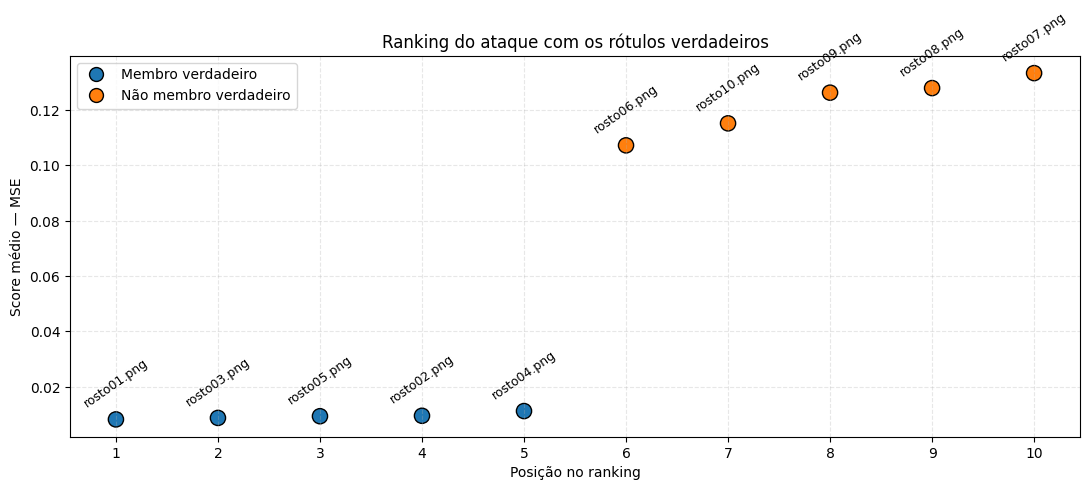

In [143]:
plt.figure(figsize=(11, 5))

plt.scatter(
    ranking.index,
    ranking["score"],
    c=cores_reais,
    s=120,
    edgecolor="black"
)

for posicao, linha in ranking.iterrows():

    plt.annotate(
        linha["imagem"],
        xy=(
            posicao,
            linha["score"]
        ),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        rotation=35
    )

legenda = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="white",
        markerfacecolor="tab:blue",
        markeredgecolor="black",
        markersize=10,
        label="Membro verdadeiro"
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        color="white",
        markerfacecolor="tab:orange",
        markeredgecolor="black",
        markersize=10,
        label="Não membro verdadeiro"
    )
]

plt.xticks(ranking.index)
plt.xlabel("Posição no ranking")
plt.ylabel("Score médio — MSE")

plt.title(
    "Ranking do ataque com os rótulos verdadeiros"
)

plt.grid(
    alpha=0.3,
    linestyle="--"
)

plt.legend(
    handles=legenda
)

plt.tight_layout()
plt.show()

In [144]:
acuracia = accuracy_score(
    rotulos_reais,
    previsoes
)

print(
    f"Acurácia do ataque: "
    f"{acuracia:.2%}"
)

Acurácia do ataque: 100.00%


In [145]:
auc = roc_auc_score(
    rotulos_reais,
    -scores
)

print(
    f"ROC AUC do ataque: "
    f"{auc:.3f}"
)

ROC AUC do ataque: 1.000


In [146]:
matriz = confusion_matrix(
    rotulos_reais,
    previsoes
)

print(matriz)

[[5 0]
 [0 5]]


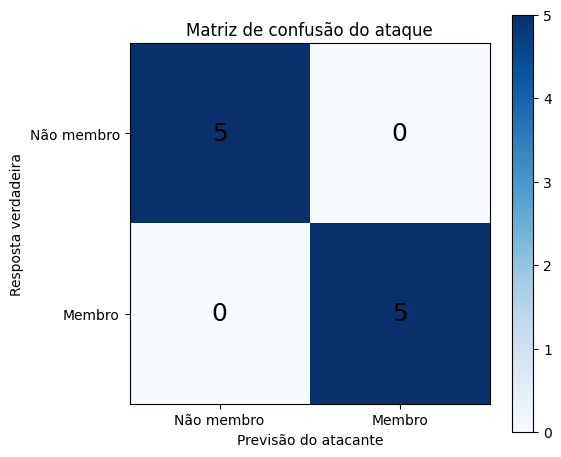

In [147]:
plt.figure(figsize=(6, 5))

plt.imshow(
    matriz,
    cmap="Blues"
)

plt.colorbar()

for linha in range(2):
    for coluna in range(2):

        plt.text(
            coluna,
            linha,
            matriz[linha, coluna],
            ha="center",
            va="center",
            fontsize=18
        )

plt.xticks(
    [0, 1],
    ["Não membro", "Membro"]
)

plt.yticks(
    [0, 1],
    ["Não membro", "Membro"]
)

plt.xlabel("Previsão do atacante")
plt.ylabel("Resposta verdadeira")
plt.title("Matriz de confusão do ataque")

plt.tight_layout()
plt.show()

## Bônus: Modelo gerando uma imagem

  0%|          | 0/50 [00:00<?, ?it/s]

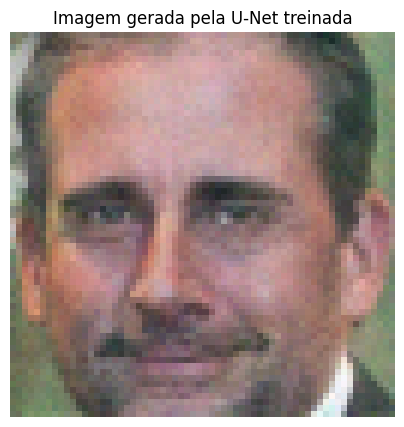

In [159]:
# Cria um scheduler mais rápido para a geração
scheduler_geracao = DDIMScheduler.from_config(
    noise_scheduler.config
)

# Usa a mesma U-Net que acabamos de treinar
pipeline = DDPMPipeline(
    unet=unet.eval(),
    scheduler=scheduler_geracao
).to(device)

# Define o ruído inicial por meio da semente
gerador = torch.Generator(
    device=device
).manual_seed(50)

# Gera uma imagem começando de ruído aleatório
with torch.no_grad():

    imagem_gerada = pipeline(
        batch_size=1,
        generator=gerador,
        num_inference_steps=50
    ).images[0]

# Mostra o resultado
plt.figure(figsize=(5, 5))
plt.imshow(imagem_gerada)
plt.title("Imagem gerada pela U-Net treinada")
plt.axis("off")
plt.show()